In [1]:
#Ejercicio. Pronóstico de Series de Tiempo con Redes Neuronales

#Obtención datos de ejemplo
# Datos adaptados de: https://totoro.banrep.gov.co/analytics/saw.dll?Go&Action=prompt&path=%2Fshared%2FSeries%20Estad%C3%ADsticas_T%2F1.%20Tasa%20de%20Cambio%20Peso%20Colombiano%2F1.1%20TRM%20-%20Disponible%20desde%20el%2027%20de%20noviembre%20de%201991%2F1.1.16.TCM_Serie%20historica_ultimos_doce%20meses&Options=rdf&lang=es

import csv
import pandas as pd
import matplotlib.pyplot as plt

# Ruta a tu archivo de etiquetas
archivo_csv = "1.1.16.TCM_Serie historica_ultimos_doce meses.csv"

# Leer el archivo CSV en un DataFrame especificando el delimitador
df = pd.read_csv(archivo_csv, delimiter=';', decimal=',')

# Asegurar que la columna 'Fecha' esté en formato datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)
df = df.drop(columns=[';'])
# Eliminar espacios en los nombres de las columnas si es necesario
df.columns = df.columns.str.strip()
# Reemplazar comas por puntos y convertir a float
# Eliminar los puntos de los miles y reemplazar comas por puntos decimales
df['TRM'] = df['TRM'].str.replace('.', '', regex=False).str.replace(',', '.').astype(float)

# Verificar resultados
print(df.head())
print("columnas", df.columns)
print("tipo", df.dtypes)  # Verifica el tipo de datos de la columna 'TRM'

       Fecha      TRM
0 2024-08-14  4038.87
1 2024-08-13  4063.26
2 2024-08-12  4064.51
3 2024-08-11  4064.51
4 2024-08-10  4064.51
columnas Index(['Fecha', 'TRM'], dtype='object')
tipo Fecha    datetime64[ns]
TRM             float64
dtype: object


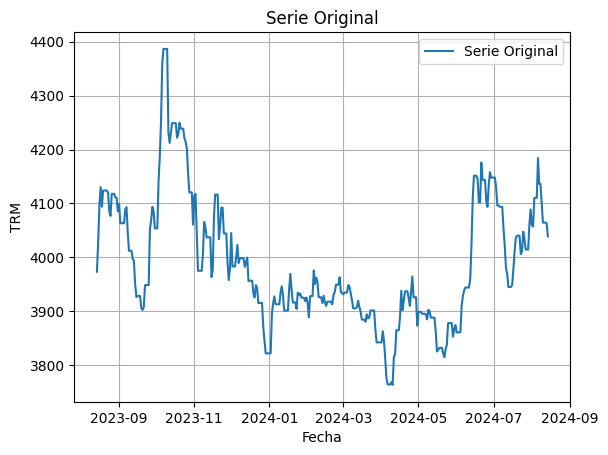

In [2]:
# Gráfica de la serie original
plt.plot(df['Fecha'], df['TRM'], label='Serie Original')
plt.title('Serie Original')
plt.xlabel('Fecha')
plt.ylabel('TRM')
plt.legend()
plt.grid(True)
plt.show()

In [3]:
#Descomposición de la serie de tiempo

import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Como se tiene el DataFrame df con las columnas 'Fecha' y 'TRM'

# Configurar la columna 'Fecha' como índice
df.set_index('Fecha', inplace=True)

# Asegurarse de que el índice sea un DatetimeIndex
if not isinstance(df.index, pd.DatetimeIndex):
    raise ValueError("El índice del DataFrame debe ser un DatetimeIndex.")

#Nota: Después de establecer la columna 'Fecha' como índice, no estará disponible
#como una columna en el DataFrame df. Por tanto, debe volverse a ejecutar todo el código
#porque, cuando se intenta acceder a df['Fecha'],
#se produce un KeyError porque la columna 'Fecha' no existe en el DataFrame.

# Establecer la frecuencia del índice si es necesario
df = df.asfreq('D')  # 'D' para datos diarios, ajusta si es diferente (por ejemplo, 'W' para semanal, 'M' para mensual)

# Seleccionar la serie de tiempo
ts = df['TRM']

In [4]:
#1 Preprocesamiento de datos

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split

#Dividir los datos de entrenamiento y prueba
train_data, test_data = train_test_split(ts, test_size=0.3, shuffle=False)
print("train data", train_data)
print("test data", test_data)

train data Fecha
2023-08-14    3973.41
2023-08-15    4029.95
2023-08-16    4096.08
2023-08-17    4130.33
2023-08-18    4093.96
               ...   
2024-04-21    3937.13
2024-04-22    3937.13
2024-04-23    3924.82
2024-04-24    3910.01
2024-04-25    3935.65
Freq: D, Name: TRM, Length: 256, dtype: float64
test data Fecha
2024-04-26    3964.59
2024-04-27    3926.02
2024-04-28    3926.02
2024-04-29    3926.02
2024-04-30    3873.44
               ...   
2024-08-10    4064.51
2024-08-11    4064.51
2024-08-12    4064.51
2024-08-13    4063.26
2024-08-14    4038.87
Freq: D, Name: TRM, Length: 111, dtype: float64


In [5]:
# Paso 2: Preparación de datos (ejemplo básico)
# Por ejemplo, transformamos nuestros datos en secuencias
def create_dataset(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

#Definimos el número de pasos de tiempo para la serie temporal
seq_length = 16

#Creamos las secuencias de entrenamiento y prueba en formato 3D
X_train, y_train = create_dataset(train_data, seq_length)
X_test, y_test = create_dataset(test_data, seq_length)

#Imprimimos los conjutos de datos en formato 3D
#print("Conjunto de secuencias de entrenamiento X_train:\n", X_train)
#print("Etiquetas de entrenamiento y_train:\n", y_train)
#print("Conjunto de secuencias de prueba X_test:\n", X_test)
#print("Etiquetas de prueba y_test:\n", y_test)

<ipython-input-5-efcbf7b1877d>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y.append(data[i+sequence_length])


In [6]:
#3 Contrucción del modelo
model = Sequential()
model.add(LSTM(32,
               activation='relu',
               input_shape=(seq_length, 1),
               return_sequences=True))
model.add(LSTM(32, activation='relu'))
model.add(Dense(1))
model.summary()

#4 Compilación del modelo
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 16, 32)              │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,705 (49.63 KB)

 Trainable params: 12,705 (49.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 29673124.0000
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 21940768.0000
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 22977776.0000
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 21095854.0000
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 18667898.0000
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 18295096.0000
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 17895258.0000
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 17586470.0000
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 17303314.0000
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 17398606.0000
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 13044312.0000
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 11838163.0000
Epoch 13/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 12510619.0000
Epoch 14/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1

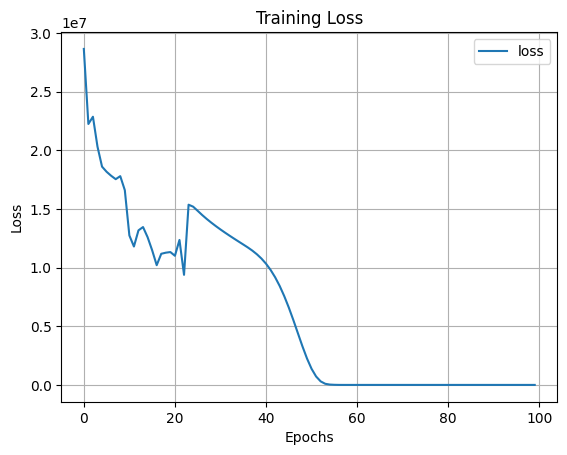

In [7]:
# Paso 5: Entrenamiento del modelo
history = model.fit(X_train, y_train, epochs=100)

# Graficar el historial de entrenamiento:
pd.DataFrame(history.history).plot(grid=True)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [8]:
#Paso 6: Evaluación del modelo
Evaluación = model.evaluate(X_test, y_test)
print("Evaluación del modelo:", Evaluación)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 11207.5811 
Evaluación del modelo: 12950.826171875


Predicción del modelo X_test:
 [[3964.59 3926.02 3926.02 ... 3902.63 3900.38 3888.21]
 [3926.02 3926.02 3926.02 ... 3900.38 3888.21 3888.21]
 [3926.02 3926.02 3873.44 ... 3888.21 3888.21 3888.21]
 ...
 [4014.56 4014.56 4014.56 ... 4100.79 4064.51 4064.51]
 [4014.56 4014.56 4059.91 ... 4064.51 4064.51 4064.51]
 [4014.56 4059.91 4089.05 ... 4064.51 4064.51 4063.26]]
Etiquetas reales y_test:
 [3888.21 3888.21 3888.21 3861.82 3825.42 3828.98 3832.26 3832.26 3832.26
 3822.39 3814.94 3829.59 3837.58 3878.07 3878.07 3878.07 3878.07 3853.09
 3867.02 3874.32 3860.92 3860.92 3860.92 3860.92 3909.65 3927.91 3938.53
 3944.14 3944.14 3944.14 3944.14 3960.83 4023.26 4107.52 4151.55 4151.55
 4151.55 4144.63 4101.87 4101.87 4175.96 4143.72 4143.72 4143.72 4104.38
 4093.66 4133.61 4158.1  4148.04 4148.04 4148.04 4148.04 4130.03 4096.09
 4096.09 4093.72 4093.72 4093.72 4052.99 4022.05 3979.91 3968.87 3944.97
 3944.97 3944.97 3948.41 3977.63 4011.19 4036.73 4040.2  4040.2  4040.2
 4006.01 4010.53 4047.66

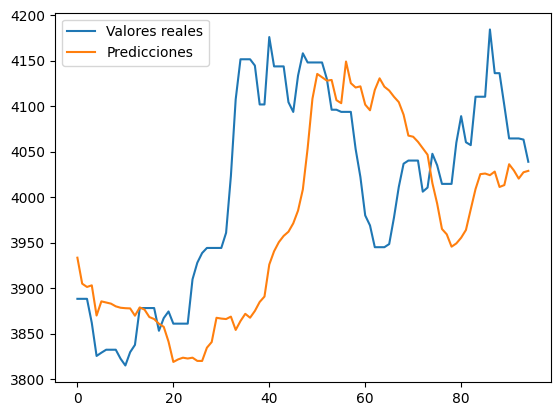

In [9]:
# Paso 7: Predicción
print("Predicción del modelo X_test:\n", X_test)
print("Etiquetas reales y_test:\n", y_test)
y_pred = model.predict(X_test)
print("Predicciones del modelo:\n", y_pred)
plt.plot(y_test, label='Valores reales')
plt.plot(y_pred, label='Predicciones')
plt.legend()
plt.show()

Predicción del modelo X_test:
 [[[3964.59]
  [3926.02]
  [3926.02]
  ...
  [3902.63]
  [3900.38]
  [3888.21]]

 [[3926.02]
  [3926.02]
  [3926.02]
  ...
  [3900.38]
  [3888.21]
  [3888.21]]

 [[3926.02]
  [3926.02]
  [3873.44]
  ...
  [3888.21]
  [3888.21]
  [3888.21]]

 ...

 [[4014.56]
  [4014.56]
  [4014.56]
  ...
  [4100.79]
  [4064.51]
  [4064.51]]

 [[4014.56]
  [4014.56]
  [4059.91]
  ...
  [4064.51]
  [4064.51]
  [4064.51]]

 [[4014.56]
  [4059.91]
  [4089.05]
  ...
  [4064.51]
  [4064.51]
  [4063.26]]]
Etiquetas reales y_test:
 [3888.21 3888.21 3888.21 3861.82 3825.42 3828.98 3832.26 3832.26 3832.26
 3822.39 3814.94 3829.59 3837.58 3878.07 3878.07 3878.07 3878.07 3853.09
 3867.02 3874.32 3860.92 3860.92 3860.92 3860.92 3909.65 3927.91 3938.53
 3944.14 3944.14 3944.14 3944.14 3960.83 4023.26 4107.52 4151.55 4151.55
 4151.55 4144.63 4101.87 4101.87 4175.96 4143.72 4143.72 4143.72 4104.38
 4093.66 4133.61 4158.1  4148.04 4148.04 4148.04 4148.04 4130.03 4096.09
 4096.09 4093.72 40

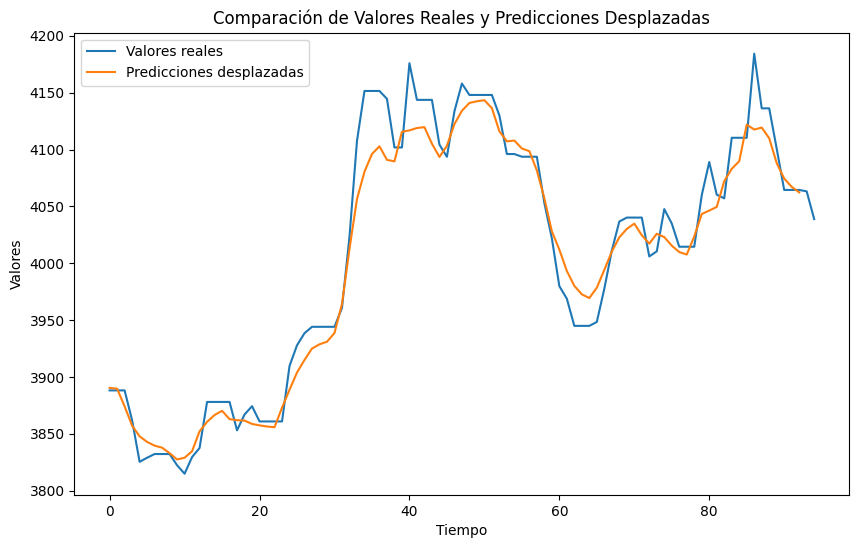

In [21]:
#Ajustando el pronóstico porque se mantiene la tendencia
import numpy as np
import matplotlib.pyplot as plt

# Paso 7: Predicción
print("Predicción del modelo X_test:\n", X_test)
print("Etiquetas reales y_test:\n", y_test)
y_pred = model.predict(X_test)
print("Predicciones del modelo:\n", y_pred)

# Desplazar las predicciones 2 puntos a la izquierda
shift = 2
shifted_y_pred = y_pred.flatten()[shift:]  # Recortar los primeros 10 valores

# Añadir NaN al final para mantener la longitud original
shifted_y_pred = np.concatenate([shifted_y_pred, np.full(shift, np.nan)])

# Ajustar la longitud de y_test para que coincida con shifted_y_pred
if len(shifted_y_pred) > len(y_test):
    shifted_y_pred = shifted_y_pred[:len(y_test)]
else:
    y_test = y_test[:len(shifted_y_pred)]

# Graficar los valores reales y las predicciones desplazadas
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Valores reales')
plt.plot(shifted_y_pred, label='Predicciones desplazadas')
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Valores')
plt.title('Comparación de Valores Reales y Predicciones Desplazadas')
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step
LSTM MSE: 15306.423828125
SimpleRNN MSE: 3662.541748046875
GRU MSE: 1675.5582275390625
El mejor modelo es: GRU con un MSE de 1675.5582275390625


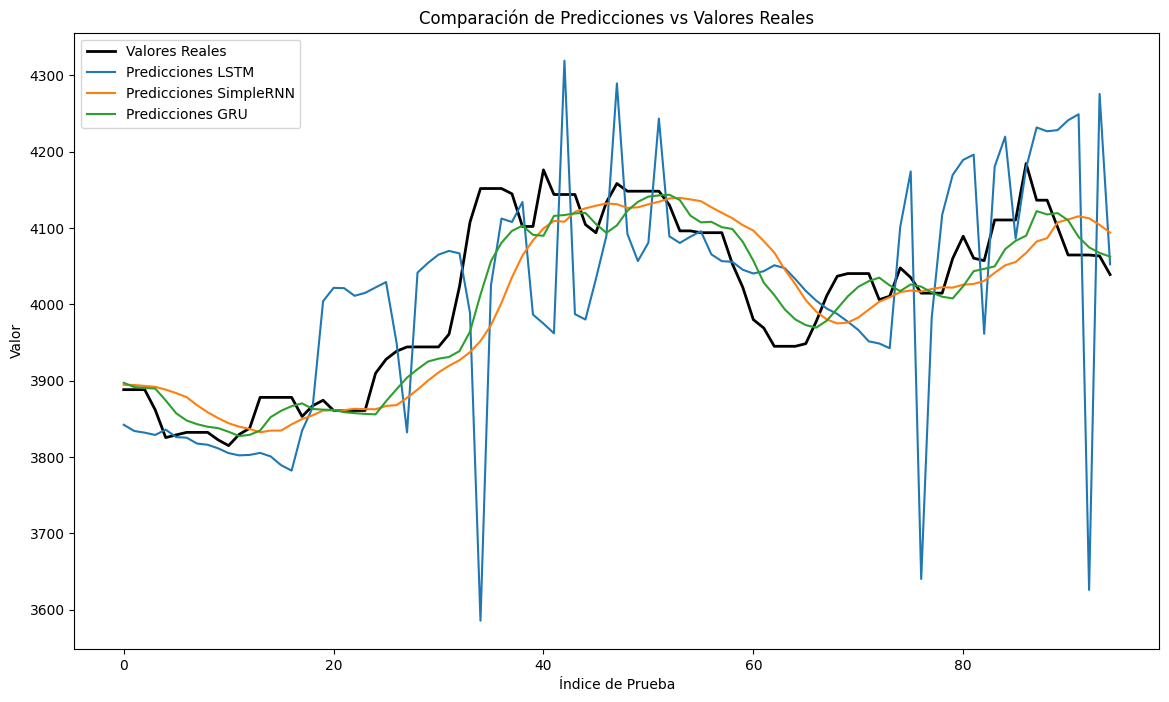

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, SimpleRNN, GRU, Dense
from sklearn.metrics import mean_squared_error
import pandas as pd

# Como se tienen los datos preparados en X_train, X_test, y_train, y_test
# Asegurando de que X_train y X_test tengan la forma correcta
if len(X_train.shape) == 2:
    # Reshape si es necesario, asumiendo que quieres usar toda la secuencia como un único timestep
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


# Función para crear y entrenar un modelo
def create_and_train_model(model_type, input_shape):
    model = Sequential()
    if model_type == 'LSTM':
        model.add(LSTM(32, activation='relu', input_shape=input_shape, return_sequences=True))
        model.add(LSTM(32, activation='relu'))
    elif model_type == 'SimpleRNN':
        model.add(SimpleRNN(32, activation='relu', input_shape=input_shape, return_sequences=True))
        model.add(SimpleRNN(32, activation='relu'))
    elif model_type == 'GRU':
        model.add(GRU(32, activation='relu', input_shape=input_shape, return_sequences=True))
        model.add(GRU(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    model.fit(X_train, y_train, epochs=50, verbose=0)
    return model

# Crear y entrenar los modelos
input_shape = (X_train.shape[1], 1)
models = {
    'LSTM': create_and_train_model('LSTM', input_shape),
    'SimpleRNN': create_and_train_model('SimpleRNN', input_shape),
    'GRU': create_and_train_model('GRU', input_shape)
}

# Evaluar los modelos
mse_scores = {}
predictions = {}

for model_name, model in models.items():
    mse = model.evaluate(X_test, y_test, verbose=0)
    mse_scores[model_name] = mse
    predictions[model_name] = model.predict(X_test)

# Mostrar los MSEs
for model_name, mse in mse_scores.items():
    print(f"{model_name} MSE: {mse}")

# Determinar el mejor modelo
best_model = min(mse_scores, key=mse_scores.get)
print(f"El mejor modelo es: {best_model} con un MSE de {mse_scores[best_model]}")

# Graficar las predicciones vs los valores reales para cada modelo
plt.figure(figsize=(14, 8))
plt.plot(y_test, label='Valores Reales', color='black', linewidth=2)

for model_name, y_pred in predictions.items():
    plt.plot(y_pred, label=f'Predicciones {model_name}')

plt.title('Comparación de Predicciones vs Valores Reales')
plt.xlabel('Índice de Prueba')
plt.ylabel('Valor')
plt.legend()
plt.show()

#Conclusión

El GRU tiene el MSE más bajo (1675.56), lo que indica que sus predicciones están, en promedio, más cerca de los valores reales que las predicciones de los modelos LSTM o SimpleRNN. Por esta razón, se considera que el GRU es el mejor modelo en este caso específico.